# Fysikkprosjekt

## Oppgave 1

### 1a

Vi har

$$
\frac{d^2 y}{dx^2} = -4\sin(2x),\qquad y(0)=0,\qquad y'(0)=2.
$$

ved å ta integralet

$$
\frac{dy}{dx} = \int -4\sin(2x) \;dx = 2\cos(2x) + c
$$

setter vi inn for $y'(0)=2$

$$
2\cos(0) + c = 2  \qquad \Leftrightarrow \qquad c = 0
$$

Så integrerer vi en gang til

$$
y = \int 2\cos(2x) \; dx = \sin(2x) + c
$$

hvor vi setter inn $y(0) = 0$

$$
\sin(0) + c = 0  \qquad \Leftrightarrow \qquad c = 0
$$

altså er løsningen til $\frac{d^2 y}{dx^2}$

$$
y = \sin(2x)
$$

### 1b

Putter svarene fra 1a i en vektor
$$
\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x) \end{pmatrix} =
\begin{pmatrix} \sin(2x) \\ 2\cos(2x) \end{pmatrix} \qquad ,\qquad 
\vec{y}(0) = \begin{pmatrix} 0 \\ 2 \end{pmatrix}
$$

### 1c

1071 1072


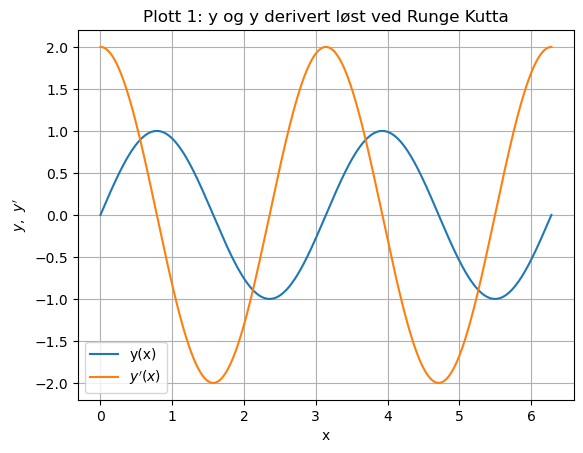

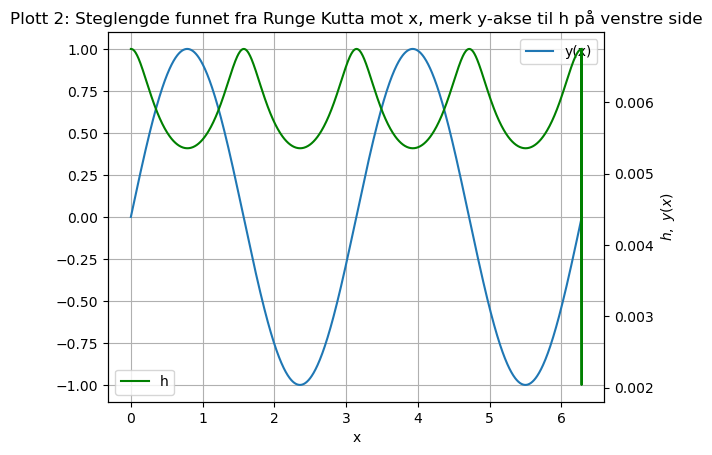

1071 1072


In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import time

#Runge-Kutta metode
def RK(x_init,x_end,y_init,h0,tol,f,alpha):
    #Definerer variabler i lister
    h = [h0] #Steglengde mellom hvert steg, x_(n) - x_(n-1)
    h_with_discarded = [h0]   #Alle steglengder blir lagt til i listen, uavhengig om de er innenfor toleransen satt
    x = [x_init]   
    y_1 = [y_init[0]]   # y, svaret på likningen gitt 
    y_2 = [y_init[1]]   # y'
    n = 0   #Antall steg tatt
    
    #Selve metode for å regne Runge-Kutta
    k_1 = f(x[n], np.array([y_1[n], y_2[n]]))
    while x_end - x[n] > 0:
        y_cur = np.array([y_1[n], y_2[n]])
        h[n] = min(h[n],x_end - x[n])
    
        
        k_2 = f(x[n] + 1/2*h[n], y_cur + 1/2*h[n]*k_1)
        k_3 = f(x[n] + 3/4*h[n], y_cur + 3/4*h[n]*k_2)
        y_new = y_cur + 1/9*h[n]*(2*k_1 + 3*k_2 + 4*k_3)

        k_4 = f(x[n]+h[n],y_new)
        z_new = y_cur + 1/24*h[n]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        
        est = np.sqrt(np.sum((y_new - z_new)**2))

        h_new = alpha*h[n]*(tol/est)**(1/3)
        h_with_discarded.append(h_new)

        if est < tol:
            x.append(x[n] + h[n])
            y_1.append(y_new[0])
            y_2.append(y_new[1])
            n = n + 1
            k_1 = k_4
            h.append(h_new)
        else:
            h[n] = h_new
    return x, y_1,y_2, h, h_with_discarded

#funsjon som brukes i oppgave 1c-1f
def f(x,y):
    return np.array([y[1],-4*np.sin(2*x)])

        
def oppg_c():
    #oppgitte verdier
    x_init = 0
    x_end = 2*np.pi
    alpha = 0.8  #"Pessimistfaktor" for h
    tol = 10**-7 #Toleranse
    y_init = np.array([0.,2.]) #y_init er en vektor der y_init[0] = y(altså løsningen)  og y_init[1] = y'
    h0 = 0.01  #Første steglengde


    x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)

    #Plotter y og y' mot x
    plt.plot(x, y_1, label = 'y(x)')
    plt.plot(x, y_2, label = r"$y'(x)$")
    print(len(h),len(h_w_disc))
    plt.xlabel("x")
    plt.ylabel(r"$y,\ y'$")
    plt.title('Plott 1: y og y derivert løst ved Runge Kutta')
    plt.grid()
    plt.legend()
    plt.show()

    #Plotter h og y mot x, merk to ulike y-akser
    fig, ax1 = plt.subplots()
    ax1.plot(x, y_1, label = 'y(x)')
    plt.grid()
    ax2 = ax1.twinx()
    ax2.plot(x, h, color = 'g', label = 'h')
    ax1.set_xlabel('x')
    plt.ylabel(r"$h,\ y(x)$")
    ax2.legend()
    ax1.legend()
    plt.title('Plott 2: Steglengde funnet fra Runge Kutta mot x, merk y-akse til h på venstre side')
    plt.show()
    print(len(h),len(h_w_disc))

oppg_c()


I plot 1 ser man løsningen til y'' funnet med Runge-Kutta-metoden (RK). Disse er gangske lik den analytiske løsningen, mer om det senere.

I plott 2 ser man steglengden h som regnes for hvert steg i RK og y, dette for å vise sammenhengen mellom dem. Og som det vises blir steglengden kortere når, altså mindre h-verdi, når tangenten endres mye fra et punkt til neste, og h blir større når løsningen oppfører seg mer lineært. Det gir altså mening. Merk også at det er to y-akser, der den til høyre angir h-verdier og den til venstre angir y(x).


### 1d

C:\Users\H8k3y\AppData\Local\Temp\ipykernel_21940\3162099372.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


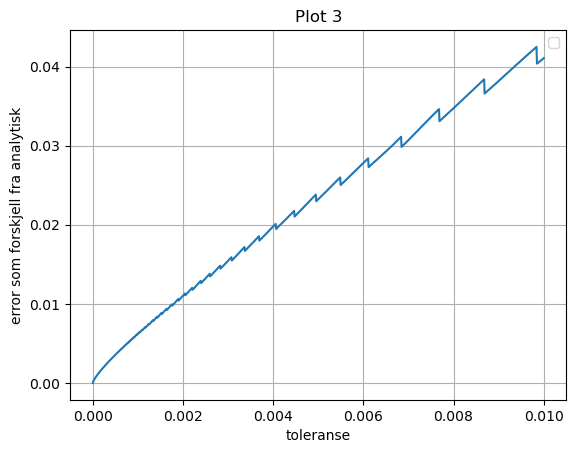

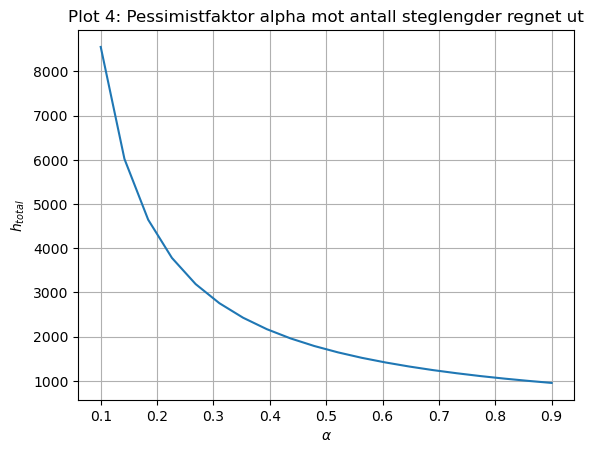

In [114]:
#Den analytiske løsningen til likningen i oppgave 1a
def y_anal(x):
    return np.sin(2*np.array(x))

def oppg_d():
    #Definerer variable
    x_init = 0
    x_end = 2*np.pi
    y_init = np.array([0.,2.])   
    h0 = 0.001   
    alpha = 0.8  

    #Lager en listen med ulike toleranseverdier for å plott dem mot erroren
    tol_list_len = 1000
    tol_list = np.linspace(10**(-9),10**(-2),tol_list_len)
    error_list =[]

    #Itererer gjennom de ulike toleransene og regner ut erroren 
    for tol in tol_list:
        x, y_1_built, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)
        error_list.append(np.sum(np.absolute(y_anal(x) - y_1_built)))
        
    #Plotter
    plt.plot(tol_list, error_list)
    plt.xlabel('toleranse')
    plt.ylabel('error som forskjell fra analytisk')
    plt.title('Plot 3')
    plt.grid()
    plt.legend()
    plt.show()

    ############################################################################################
    #Definerer variabel, resten er definert fra før
    tol = 10**(-7)

    #Lager en liste med ulike alphaverdier for å plotte mot antall steglengder RK regner ut
    alpha_list_len = 20
    list_alpha = np.linspace(0.1,0.9,alpha_list_len)
    h_tot_w_disc_list = []

    #Itererer gjennom de ulike alphaene og finner alle steglengdene som blir regnet, også forkastede
    for alpha in list_alpha:
        x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)
        h_tot_w_disc_list.append(len(h_w_disc))

    #Plotter
    plt.plot(list_alpha,h_tot_w_disc_list)
    plt.ylabel(r'$h_{total}$')
    plt.xlabel(r'$\alpha$')
    plt.title('Plot 4: Pessimistfaktor alpha mot antall steglengder regnet ut')
    plt.grid()
    plt.show()

oppg_d()
  

I plott 3 ser man hvordan en økende toleranse gir en større error, dette gir mening da en mindre toleranse krever en løsning som er mer riktig, gjennom å utføre et ekstra steg med RK og sammenligne og deretter muligens forkaste svaret. Hvorfor grafen har sagtenner er uvisst.

I plott 4 ser mat at antall utregnede steg minker med økende alpha. Dette gir mening da størrelsen på $\alpha$ er proposjonal med den nye steglengden. Dette ser man i $ h_{new} = \alpha h_n (tol/est)^{1/3}$. $\alpha$ er altså en parameter man lett kan justere på hvis man ønsker større eller mindre steg for alle iterasjoner.

### 1e

In [108]:
#Funksjon bruk i oppgave 1e
def g(z):
    return z + np.sin(z) + np.cos(z)

#Sekantmetoden, returnerer en liste med alle gjettede x i g(x), der x[-1] gir g(x[-1]) = 0
def secant(g, z_0, z_1, tol):
    z = [z_0,z_1]
    n = 1
    while np.absolute(z[n-1] - z[n]) >= tol:
        z.append((z[n-1]*g(z[n]) - z[n]*g(z[n-1]))/(g(z[n]) - g(z[n-1])))
        n = n + 1
    return z


def oppg_e():
    #Finner roten til g med sekantmetoden
    z = secant(g,12,10,10**(-7))
    print(f'Roten av g er ved z = {z[-1]}')
    
    if g(z[-1]) == 0:
        print('z funnet gir 0')
    elif np.abs(g(z[-1])) < 1e-15:
        print(f'g(z) = {g(z[-1])}, som ikke akkurat 0, men den er ekstremt nært')

oppg_e()


Roten av g er ved z = -0.4566247045676308
g(z) = -1.1102230246251565e-16, som ikke akkurat 0, men den er ekstremt nært


Metoden gir ikke akkurat 0, men den gir en verdi nær nok. Det skjekkes ved å putte inn funnet z i g.

### 1f

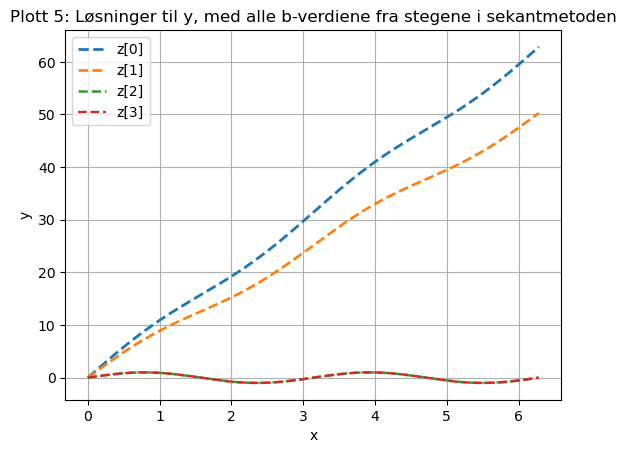

In [109]:
#Boundry value problem solver
def BVP(x_init, x_end, y_init_BVP, f):
    #Her er y_init_BVP et array med to elementer med verdien til randbetingelsene,
    #i denne oppgaven er de begge 0
    #Definerer variable som holdes konstant i denne oppgaven
    b_0 = 12
    b_1 = 10
    tol = 10**(-7)
    alpha = 0.8
    h0 = 0.001
    
    
    #Definerer en funksjon som gir y-verdien på x_end, der b = y'
    def y_at_end(b):
        x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, np.array([y_init_BVP[0],b]), h0, tol, f, alpha)
        return y_1[-1] - y_init_BVP[1]
    b_cor = secant(y_at_end, b_0, b_1, tol) #Gir den korrekte b-verdien i b_cor[-1]
    x_list = []
    y_list = []


    #itererer gjennom de ulike b-ene som ble funnet med sekantmetoden og legger verdiene i liste
    for b in b_cor:
        y_init = np.array([0.,b])
        x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)
        x_list.append(x)
        y_list.append(y_1)

    #returnerer listene med listene med lister av x- og y-verdier og listen med b-verdier
    return  x_list, y_list, b_cor

def oppg_f():
    #Bruker BVP til å løse 1a
    x_list, y_list, b = BVP(0,2*np.pi, np.array([0,0]),f)
    
    #Plotter alle løsningene med ulik b-verdi funnet med sekantmetoden
    for x in range(len(b)):
        plt.plot(x_list[x],y_list[x], linewidth = 2 - x/10, linestyle = '--', label = f'z[{x}]')
    
    #Plotter
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Plott 5: Løsninger til y'', med alle b-verdiene fra stegene i sekantmetoden')
    plt.grid()
    plt.legend()
    plt.show()

oppg_f()


Plott 5 viser de ulike løsningene y, hvor alle stegene i sekantmetoden plottes, ikke bare løsningen til sekantmetoden. z[0] og z[1] er gjett vi har valgt selv, også finner sekantmetoden z[3] og z[4]. Plottet viser at den er svært effektiv, at det nesten er suspekt, da den regner ut z[4] og ser at den er ekstremt nært z[3] og returnerer z. Den klarer altså å finne den riktige roten på praktisk talt bare en iterasjon.

### 1g

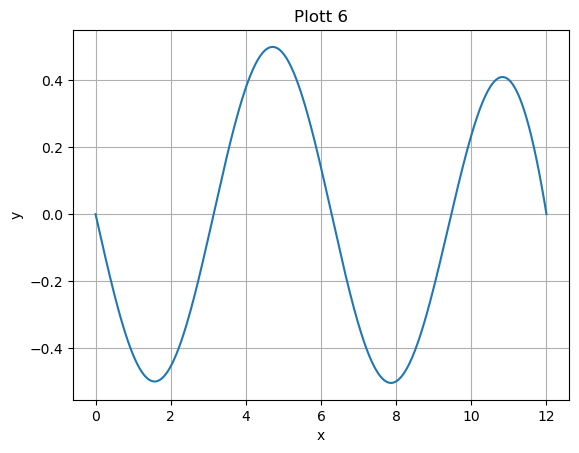

In [110]:
#Funksjon som brukes i 1g og 1h
def F(x,y):
    return np.array([y[1],y[0] + np.sin(x)])

def oppg_g():
    #Bruker den selvlagde løseren
    y = np.array([0,0])
    x_list, y_list, z = BVP(0,12, y, F)

    #Plotter
    plt.plot(x_list[-1],y_list[-1], label = 'BVP')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Plott 6')
    plt.grid()
    plt.show()

oppg_g()

Plott 6 er løsningen på gitte funksjon F, gitt med løseren vi har laget selv. Neste oppgave når det plottes med scipy vil det vise seg om dette faktisk stemmer.

### 1h

Tid brukt på vår randverdiproblemløser(RVPL): 6.4886464000010164 
Tid brukt på scipy sin randverdiproblemløser: 0.002491400002327282


C:\Users\H8k3y\AppData\Local\Temp\ipykernel_21940\3734459583.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


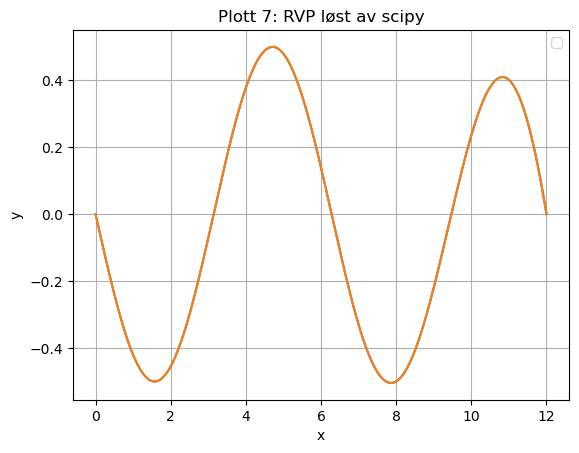

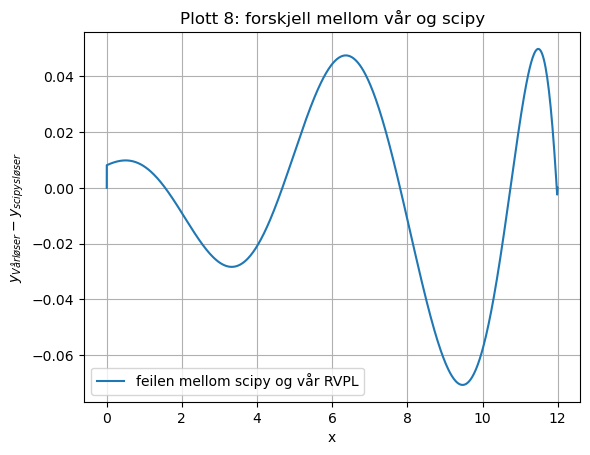

In [ ]:

def oppg_h():
    #Initialverdien oppgitt
    y_init_BVP = np.array([0,0])

    #For å løse likningen med scipy
    def bc(ya, yb):
        return np.array([ya[0] - y_init_BVP[0], yb[0] - y_init_BVP[1]]) 

    #Tar tiden til vår løser
    t_own_start = time.perf_counter()
    x_list, y_list, z = BVP(0,12, y_init_BVP, F)
    t_own_end = time.perf_counter()
    t_own = t_own_end - t_own_start
    
    #Lager verdier til scipy fra vår liste for å ha samme antall verdier, lettere med plotting
    x = np.linspace(0,12,len(y_list[-1]))
    y_a = np.zeros((2, x.size))

    #Tar tiden scipy bruker for å løse
    t_sci_start = time.perf_counter()
    res = solve_bvp(F, bc, x, y_a)
    t_sci_end = time.perf_counter()
    t_sci = t_sci_end - t_sci_start

    #svaret fra scipy
    y = res['y']

    #Skriver ut hvor lang tid begge tar
    print(f'Tid brukt på vår randverdiproblemløser(RVPL): {t_own} \nTid brukt på scipy sin randverdiproblemløser: {t_sci}')

    #Plotter både vår og scipys løsning
    plt.plot(x_list[-1], y_list[-1])
    plt.plot(x, y[0])
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Plott 7: RVP løst av scipy')
    plt.grid()
    plt.legend()
    plt.show()

    #Plotter forskjellen
    plt.plot(x_list[-1], y_list[-1] - y[0], label = 'feilen mellom scipy og vår RVPL')
    plt.xlabel('x')
    plt.ylabel(r'$y_{Vår løser} - y_{scipys løser}$')
    plt.title('Plott 8: forskjell mellom vår og scipy')
    plt.grid()
    plt.legend()
    plt.show()

oppg_h()





I plott 7 ser man løsningen til scipy, og for å vise hvor nær vår løser var er, er i tillegg den også plottet, men plottet ble bak scipys. Videre er plott 8 forskjellen mellom vår løser og scipys løser. Det er nok ikke tvil om at det er scipys løsning som er nærmere den sanne verdien enn vår, men interessant er at feilen ser ut til å begynne å oscillere fortere. Om dette fortsetter slik etter x = 12 er uvisst. I tillegg er scipys løser betraktelig mye raskere, og ikke bare litt, men med en størrelsesorden på 3 i forskjell. Det er altså ikke et spørsmål om hvilke som er bedre å bruke.